In [9]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


In [ ]:

from matplotlib import projections
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# **EDA Section**

In [27]:
df.shape


(200, 5)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [12]:
df.describe()  

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


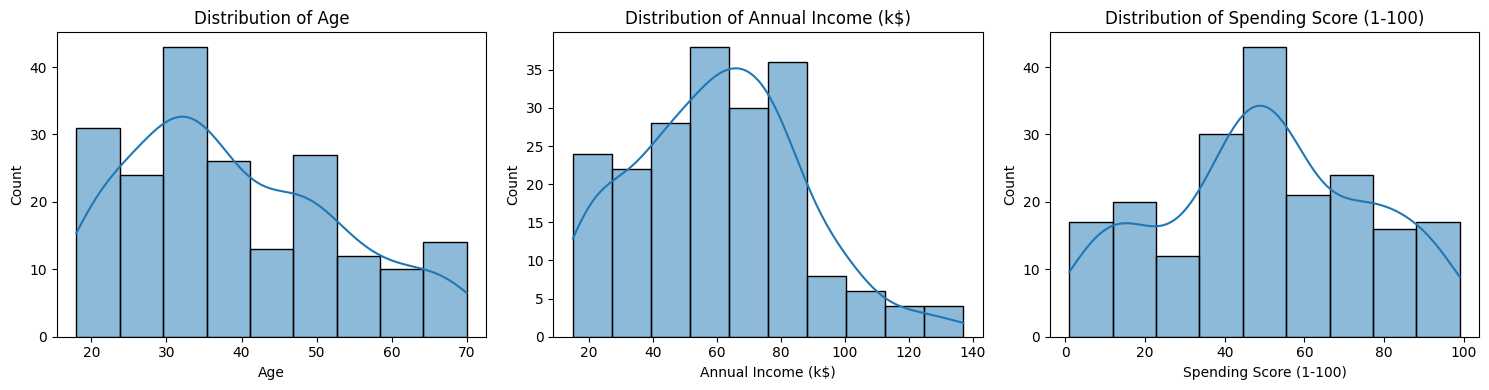

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

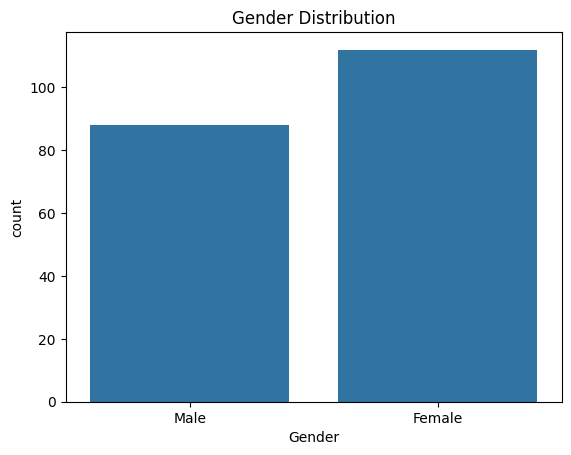

In [25]:
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.show()


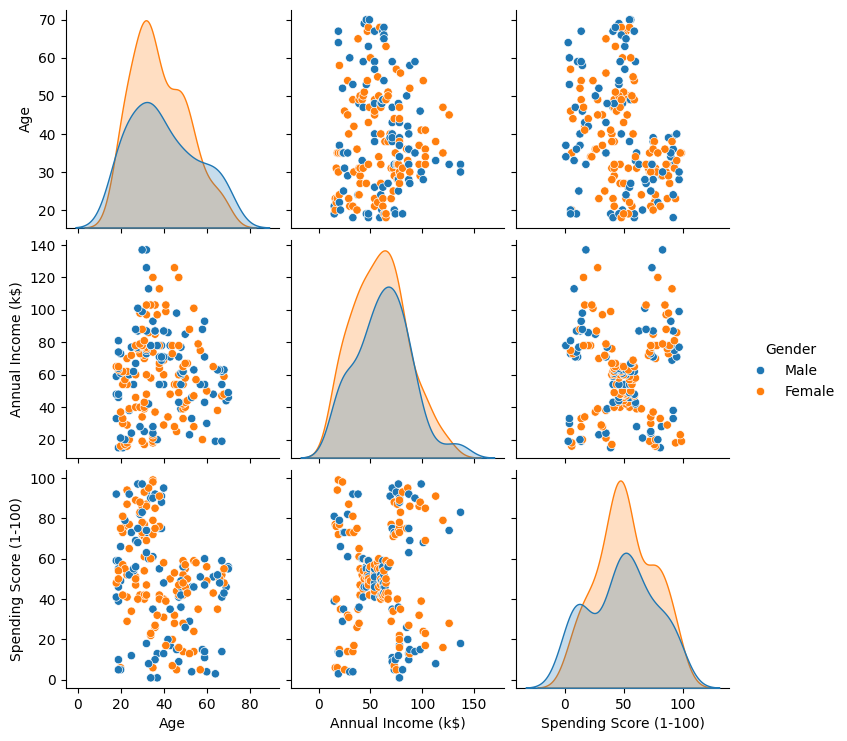

In [26]:
sns.pairplot(df.drop('CustomerID', axis=1), hue='Gender')
plt.show()

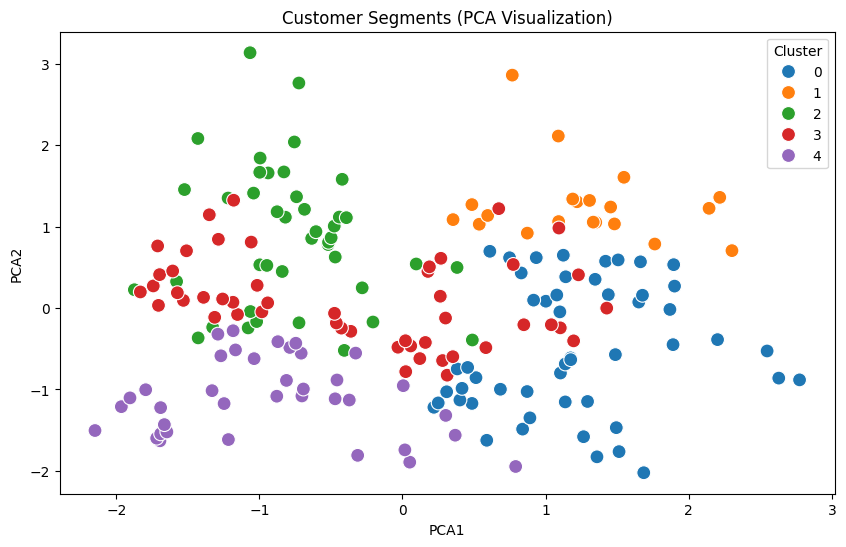

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Drop non-numeric and ID columns
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].copy()

# Encode gender
features['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Scale
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

# Cluster in full feature space
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled)

# Reduce to 2D only for visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled)
df['PCA1'] = pca_data[:, 0]
df['PCA2'] = pca_data[:, 1]

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='tab10', s=100)
plt.title('Customer Segments (PCA Visualization)')
plt.show()

In [29]:
# Profile each cluster
profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
profile['Size'] = df['Cluster'].value_counts().sort_index()

# Give business labels (adjust based on what you actually see)
labels = {
    0: 'Budget Shoppers',
    1: 'Premium Targets',
    2: 'Young Spenders',
    3: 'Careful High Earners',
    4: 'Senior Loyalists'
}
profile['Segment Label'] = profile.index.map(labels)
print(profile)

          Age  Annual Income (k$)  Spending Score (1-100)  Size  \
Cluster                                                           
0        56.5                46.1                    39.3    51   
1        39.5                85.2                    14.0    20   
2        28.7                60.9                    70.2    42   
3        37.9                82.1                    54.4    49   
4        27.3                38.8                    56.2    38   

                Segment Label  
Cluster                        
0             Budget Shoppers  
1             Premium Targets  
2              Young Spenders  
3        Careful High Earners  
4            Senior Loyalists  


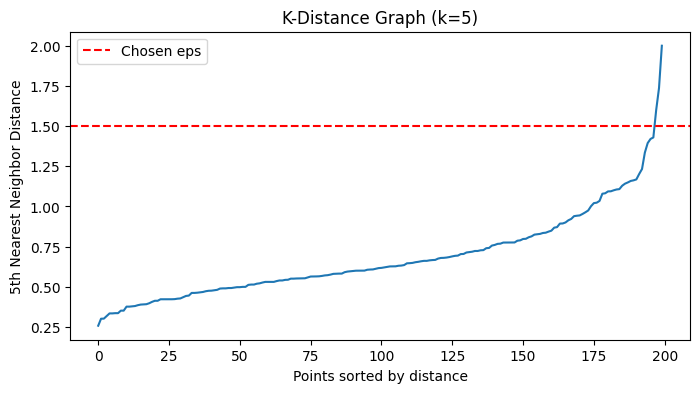

Clusters found: 1
Outliers: 0


In [30]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# Fit nearest neighbors
nn = NearestNeighbors(n_neighbors=5)
nn.fit(scaled)
distances, _ = nn.kneighbors(scaled)

# Sort distances to the 5th neighbor
distances = np.sort(distances[:, 4])

# Plot k-distance graph
plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title('K-Distance Graph (k=5)')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.axhline(y=1.5, color='r', linestyle='--', label='Chosen eps')  # adjust after looking at the plot
plt.legend()
plt.show()

# Now run DBSCAN with the eps you pick from the elbow
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)  # update eps after inspecting the plot
df['DBSCAN_Cluster'] = dbscan.fit_predict(scaled)
print(f"Clusters found: {len(set(df['DBSCAN_Cluster'])) - 1}")
print(f"Outliers: {(df['DBSCAN_Cluster'] == -1).sum()}")

In [31]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

results = {}

# K-Means
km_labels = df['Cluster']
results['K-Means'] = {
    'Silhouette Score': round(silhouette_score(scaled, km_labels), 3),
    'Davies-Bouldin Index': round(davies_bouldin_score(scaled, km_labels), 3),
    'Num Clusters': len(set(km_labels)),
    'Outliers': 0
}

# DBSCAN (exclude outliers for metric calc)
db_labels = df['DBSCAN_Cluster']
mask = db_labels != -1
results['DBSCAN'] = {
    'Silhouette Score': round(silhouette_score(scaled[mask], db_labels[mask]), 3),
    'Davies-Bouldin Index': round(davies_bouldin_score(scaled[mask], db_labels[mask]), 3),
    'Num Clusters': len(set(db_labels)) - 1,
    'Outliers': (db_labels == -1).sum()
}

import pandas as pd
print(pd.DataFrame(results).T)

         Silhouette Score  Davies-Bouldin Index  Num Clusters  Outliers
K-Means             0.272                 1.181           5.0       0.0
DBSCAN              0.278                 1.612           1.0       0.0
